# Testing centroid options: line fit + manual seam offsets

A sandbox for how the stitched waterfalls track the beam centroid. It builds the
real 4-segment `l=1` run three ways and shows the stitched waterfalls side by
side so the seam jump — and the fix — are visible.

**The three centroid options**

1. **`per_frame`** — the beam centroid is found independently in every frame
   (original behaviour). Carries shot-noise / rounding wobble.
2. **`line`** — replace it with a straight line `centroid(z)=slope·z+offset`,
   fit **per segment** with its own slope *and* offset
   (`fit_centroid_lines(shared_slope=False)`). Smooth within a segment, but
   because each segment is fit independently the lines **disagree at the seams**,
   so the beam steps sideways where the stitch hands off.
3. **`line+offset`** — the same per-segment line fits (**slopes untouched**),
   with a **manual offset at each stitching point** that slides the whole
   downstream segment up/down (`apply_seam_offsets`) until the lines meet across
   the seam. `seam_jumps` gives a jump-closing starting value for each offset;
   you then tune `SEAM_OFFSET` by hand. This is the transverse analogue of the
   hand-tuned `STARTS_MM` shift along z.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from centroid_lines import (
    fit_centroid_lines, seam_jumps, apply_seam_offsets, continuous_knots,
    fit_sections_for_plot, plot_centroid_fit,
)


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
OPTIMAL_ROOT = REPO_ROOT / "data" / "focusing_images" / "7-27-26" / "29_n15" / "Optimal"

ELL = 1
STEP_MM = 0.5

# ---- centroid / slicing knobs (verbatim from waterfall_l1_4seg) ----
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200

# segment label -> folder, chain order (increasing z)
SEGMENTS = {
    "0-25":  OPTIMAL_ROOT / "0mm-25mm",
    "20-45": OPTIMAL_ROOT / "20mm-45mm",
    "40-65": OPTIMAL_ROOT / "40mm-65mm",
    "60-85": OPTIMAL_ROOT / "60mm-85mm",
}
SEG_LABELS = list(SEGMENTS)
SEG_REF = SEG_LABELS[0]
SEAMS = list(zip(SEG_LABELS[:-1], SEG_LABELS[1:]))

# hand-set global z starts, verbatim from waterfall_l1_4seg (reference pinned at 0)
STARTS_MM = {"0-25": 0.0, "20-45": 24.5, "40-65": 45.5, "60-85": 69.0}

print(f"repo root : {REPO_ROOT}")
print(f"l={ELL}, {len(SEGMENTS)} segments: {' -> '.join(SEG_LABELS)}")


repo root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
l=1, 4 segments: 0-25 -> 20-45 -> 40-65 -> 60-85


In [2]:
# --- frame loading + per-frame centroid (copied from waterfall_l1_4seg) ---
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    return sorted((p for p in directory.glob("*.tif") if not p.name.startswith(".")),
                  key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    csv = directory / "positions.csv"
    if csv.is_file():
        by_name = dict(zip(*pd.read_csv(csv)[["image", "position_mm"]].values.T))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
    print(f"  ! {directory.parent.name}: unusable positions.csv — inferring z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frames[i] = np.asarray(Image.open(path), dtype=np.float32)
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    return cy, cx, float(signal.max())


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


In [3]:
# One-time load: raw per-frame centroid + brightness AND the frames, per segment.
# Frames are kept so each centroid option can rebuild its waterfall without re-reading.
@dataclass
class SegData:
    label: str
    z_global: np.ndarray          # global z (mm) = local z + STARTS_MM
    frames: np.ndarray            # (n, H, W) float32
    cy_raw: np.ndarray            # raw per-frame row / col centroid + brightness
    cx_raw: np.ndarray
    w: np.ndarray


seg_data: dict[str, SegData] = {}
for lbl in SEG_LABELS:
    directory = SEGMENTS[lbl] / f"l={ELL}"
    paths = frame_paths(directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {directory}")
    z_local = load_local_positions(directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3)
    seg_data[lbl] = SegData(lbl, z_local + STARTS_MM[lbl], frames,
                            cen[:, 0], cen[:, 1], cen[:, 2])
    d = seg_data[lbl]
    print(f"{lbl:>6}  n={d.z_global.size:3d}  frames {frames.shape[1:]}  "
          f"global z {d.z_global.min():5.1f}..{d.z_global.max():5.1f} mm")

raw_sections = {lbl: dict(z=d.z_global, cy=d.cy_raw, cx=d.cx_raw, w=d.w)
                for lbl, d in seg_data.items()}


  0-25  n= 51  frames (1080, 1440)  global z   0.0.. 25.0 mm


 20-45  n= 51  frames (1080, 1440)  global z  24.5.. 49.5 mm


 40-65  n= 51  frames (1080, 1440)  global z  45.5.. 70.5 mm


 60-85  n= 51  frames (1080, 1440)  global z  69.0.. 94.0 mm


## The three centroid tracks

`per_frame` uses the raw centroids directly. `line` fits one straight line per
segment (own slope + offset). `line+offset` takes those same lines and adds the
manual `SEAM_OFFSET` at each stitching point.

In [4]:
# per-segment straight-line fit (own slope + offset) -- used by "line" and "line+offset"
lines_fit, _ = fit_centroid_lines(raw_sections, shared_slope=False)
KNOTS = continuous_knots(raw_sections, SEG_LABELS)     # seam = overlap midpoint per pair

# jump-closing suggestion for each stitching point: add this to the downstream
# segment and its line meets the upstream one at the seam (slopes untouched).
suggested = seam_jumps(lines_fit, raw_sections, order=SEG_LABELS, knots=KNOTS)
print("seams (mm)        :", ", ".join(f"{t:.2f}" for t in KNOTS))
print("suggested SEAM_OFFSET (dy, dx) px  [add to the downstream segment]:")
for right, (dy, dx) in suggested.items():
    print(f"   {right:>6}:  dy={dy:+8.3f}   dx={dx:+8.3f}")


seams (mm)        : 24.75, 47.50, 69.75
suggested SEAM_OFFSET (dy, dx) px  [add to the downstream segment]:
    20-45:  dy=  -4.625   dx=  -1.240
    40-65:  dy= +49.045   dx=-202.049
    60-85:  dy=  -5.178   dx= +45.425


In [5]:
# --- MANUAL per-stitching-point offset (EDIT BY HAND) --------------------------
# Keyed by the DOWNSTREAM segment of each seam -> (dy, dx) in px, applied
# cumulatively to that segment and everything after it.  Slopes are never
# touched.  Start from the `suggested` values printed above, then tune.
SEAM_OFFSET = {right: (round(dy, 1), round(dx, 1)) for right, (dy, dx) in suggested.items()}
# e.g. to nudge everything from 40-65 onward down by 2 px in x:
#   SEAM_OFFSET["40-65"] = (SEAM_OFFSET["40-65"][0], SEAM_OFFSET["40-65"][1] - 2.0)

lines_offset = apply_seam_offsets(lines_fit, SEAM_OFFSET, order=SEG_LABELS)

# residual jump after the manual offsets (should be ~0 at the seams you closed)
resid = seam_jumps(lines_offset, raw_sections, order=SEG_LABELS, knots=KNOTS)
print("SEAM_OFFSET in use:", SEAM_OFFSET)
print("residual seam jump after offset (dy, dx) px:",
      {k: (round(a, 2), round(b, 2)) for k, (a, b) in resid.items()})

# assemble the centroid track each option feeds to the waterfall builder
CENTROIDS = {
    "per_frame":   {lbl: (raw_sections[lbl]["cy"], raw_sections[lbl]["cx"]) for lbl in SEG_LABELS},
    "line":        lines_fit,
    "line+offset": lines_offset,
}


SEAM_OFFSET in use: {'20-45': (-4.6, -1.2), '40-65': (49.0, -202.0), '60-85': (-5.2, 45.4)}
residual seam jump after offset (dy, dx) px: {'20-45': (-0.02, -0.04), '40-65': (0.04, -0.05), '60-85': (0.02, 0.02)}


In [6]:
# --- build one segment's waterfall on a supplied centroid track ---------------
@dataclass
class SegWaterfall:
    label: str
    waterfall: np.ndarray     # (n_z, n_s) bg-subtracted, not peak-normalised
    s_px: np.ndarray
    z_global: np.ndarray
    centroid_x: np.ndarray


def build_segment(lbl: str, cy_use: np.ndarray, cx_use: np.ndarray) -> SegWaterfall:
    d = seg_data[lbl]
    frames = d.frames
    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, cy_use, cx_use
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), cx_use, cy_use
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(np.mean(centre_along)))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)
    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]
    return SegWaterfall(lbl, waterfall, s_px, d.z_global, np.asarray(cx_use, float))


# --- stitch the segments (hardcut: switch at each overlap midpoint) -----------
def _resample(z_src, water_src, z_grid):
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1)
    return out, covered


def stitch_hardcut(segw: dict[str, SegWaterfall], z_grid):
    s_px = segw[SEG_REF].s_px
    maps, covers = {}, {}
    for lbl, sw in segw.items():
        maps[lbl], covers[lbl] = _resample(sw.z_global, sw.waterfall, z_grid)

    w = {lbl: covers[lbl].astype(float) for lbl in SEG_LABELS}
    for left, right in SEAMS:                       # hardcut hand-off at overlap midpoint
        both = covers[left] & covers[right]
        if both.any():
            z_ov = z_grid[both]
            ramp = (z_ov <= 0.5 * (z_ov.min() + z_ov.max())).astype(float)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp
    stack = np.stack([w[lbl] for lbl in SEG_LABELS])
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]

    water = np.zeros_like(maps[SEG_REF])
    for i, lbl in enumerate(SEG_LABELS):
        water += stack[i][:, None] * maps[lbl]
    water[~good] = 0.0
    peak = float(water.max())
    if peak > 0:
        water /= peak
    return water, s_px


_z_lo = min(d.z_global[0] for d in seg_data.values())
_z_hi = max(d.z_global[-1] for d in seg_data.values())
Z_GRID = np.arange(_z_lo, _z_hi + 0.5 * STEP_MM, STEP_MM)

stitched = {}
for mode, cen in CENTROIDS.items():
    segw = {lbl: build_segment(lbl, *cen[lbl]) for lbl in SEG_LABELS}
    stitched[mode] = stitch_hardcut(segw, Z_GRID)
    print(f"{mode:>11}: stitched {stitched[mode][0].shape}")


  per_frame: stitched (189, 401)


       line: stitched (189, 401)


line+offset: stitched (189, 401)


## Stitched waterfalls, one per centroid option

Grey dashes mark the stitching points (overlap midpoints where `hardcut` hands
off). In `line` the beam should step sideways at those lines; in `line+offset`
the step is removed by the manual `SEAM_OFFSET`, and `per_frame` shows the
frame-to-frame wobble.

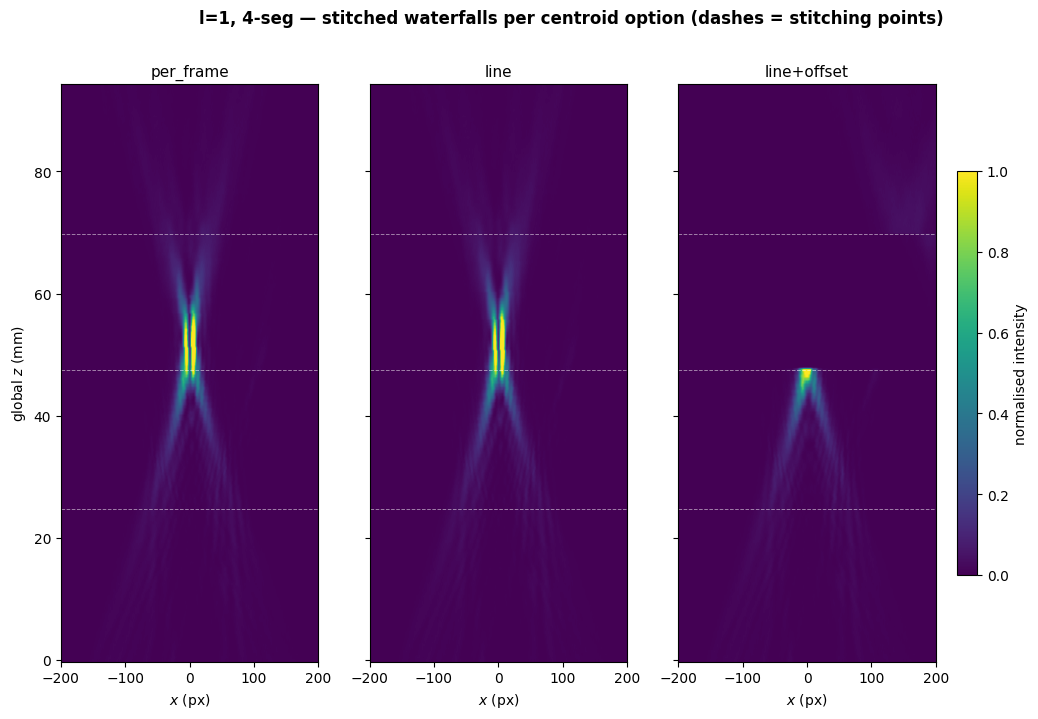

In [7]:
fig, axes = plt.subplots(1, len(CENTROIDS), figsize=(4.2 * len(CENTROIDS) + 1, 7.5),
                         sharey=True)
for ax, mode in zip(axes, CENTROIDS):
    water, s_px = stitched[mode]
    dz = float(np.median(np.diff(Z_GRID)))
    im = ax.imshow(water, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                   extent=[s_px[0], s_px[-1], Z_GRID[0] - dz / 2, Z_GRID[-1] + dz / 2])
    for t in KNOTS:
        ax.axhline(t, color="w", ls="--", lw=0.7, alpha=0.5)
    ax.set_title(mode, fontsize=11)
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
axes[0].set_ylabel("global $z$ (mm)")
fig.colorbar(im, ax=axes.tolist(), label="normalised intensity", pad=0.02, shrink=0.7)
fig.suptitle(f"l={ELL}, 4-seg — stitched waterfalls per centroid option "
             f"(dashes = stitching points)", fontweight="bold")
plt.show()


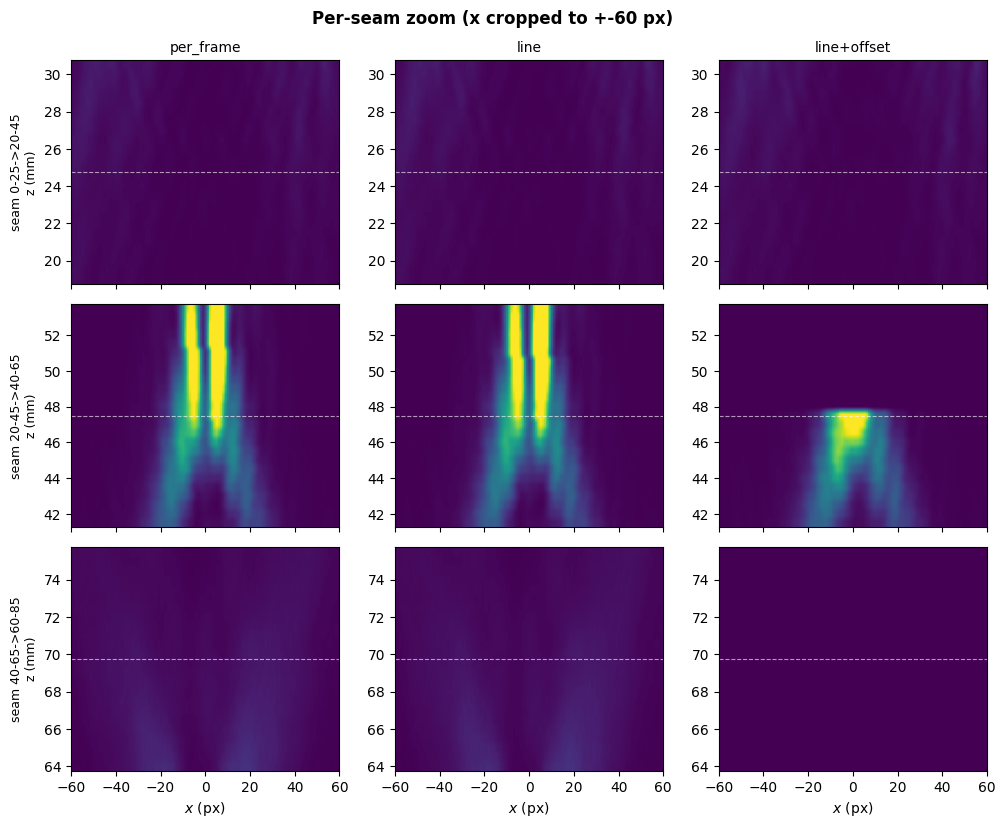

In [8]:
# zoom each seam to see the step (line) vs. the closed step (line+offset)
fig, axes = plt.subplots(len(SEAMS), len(CENTROIDS),
                         figsize=(3.4 * len(CENTROIDS), 2.8 * len(SEAMS)),
                         sharex="col")
for r, ((left, right), seam) in enumerate(zip(SEAMS, KNOTS)):
    for c, mode in enumerate(CENTROIDS):
        ax = axes[r, c]
        water, s_px = stitched[mode]
        dz = float(np.median(np.diff(Z_GRID)))
        band = (Z_GRID >= seam - 6) & (Z_GRID <= seam + 6)
        ax.imshow(water[band], origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                  extent=[s_px[0], s_px[-1], Z_GRID[band][0] - dz / 2, Z_GRID[band][-1] + dz / 2])
        ax.axhline(seam, color="w", ls="--", lw=0.8, alpha=0.6)
        if r == 0:
            ax.set_title(mode, fontsize=10)
        if c == 0:
            ax.set_ylabel(f"seam {left}->{right}\nz (mm)", fontsize=9)
        ax.set_xlim(-60, 60)
for ax in axes[-1]:
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
fig.suptitle("Per-seam zoom (x cropped to +-60 px)", fontweight="bold")
fig.tight_layout()
plt.show()


## Centroid tracks overlaid on the raw per-frame centroids

Points are the raw per-frame centroids (area ~ brightness); lines are the fits.
Grey verticals are the stitching points. Top row = the `line` fit (steps at the
seams); bottom row = `line+offset` (steps closed by `SEAM_OFFSET`).

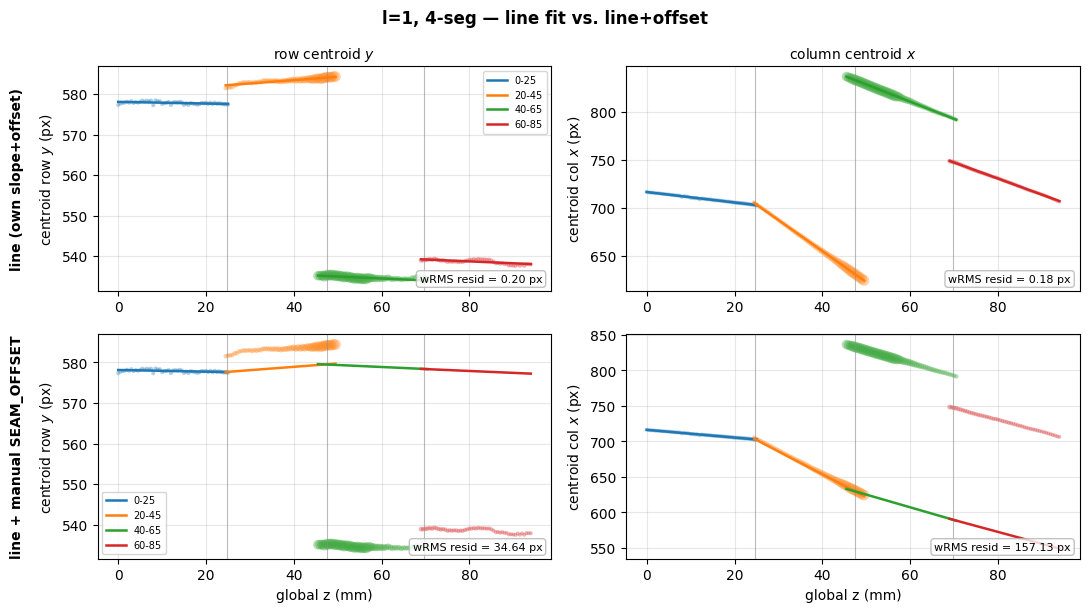

In [9]:
def sections_from_lines(lines):
    out = []
    for lbl in SEG_LABELS:
        cy_fit, cx_fit = lines[lbl]
        out.append(dict(z=raw_sections[lbl]["z"],
                        cy_raw=raw_sections[lbl]["cy"], cx_raw=raw_sections[lbl]["cx"],
                        cy_fit=np.asarray(cy_fit), cx_fit=np.asarray(cx_fit),
                        w=raw_sections[lbl]["w"], label=lbl))
    return out


fig = plot_centroid_fit(
    {"line (own slope+offset)":       sections_from_lines(lines_fit),
     "line + manual SEAM_OFFSET":     sections_from_lines(lines_offset)},
    title=f"l={ELL}, 4-seg — line fit vs. line+offset",
    show=False,
)
for ax in fig.axes:
    for t in KNOTS:
        ax.axvline(t, color="0.55", lw=0.8, alpha=0.6)
plt.show()


**Workflow.** Read the suggested `SEAM_OFFSET` printed above (the values that
close each seam), drop them into the `SEAM_OFFSET` cell, then nudge by hand while
watching the per-seam zoom until each stitching point is clean. Because the
offsets are cumulative downstream, tune the seams top-to-bottom: fix the first,
then the second, and so on.

Once happy, the same recipe ports into the stitched notebooks: fit with
`fit_centroid_lines(..., shared_slope=False)`, then
`apply_seam_offsets(lines, SEAM_OFFSET, order=SEG_LABELS)` before building each
segment's waterfall.